# Q-learning GridWorld + animated learning-curve graph.

    - x: episode number
    - y: steps taken to reach the goal (lower is better)
    - a dot moves step-by-step across episodes, and the curve grows with it
    - Speed control:Set FRAME_MS (milliseconds per frame)



In [1]:


import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# =========================
# Speed parameter (edit me)
# =========================
FRAME_MS = 50  # ms per episode frame (e.g., 20 fast, 50 normal, 200 slow)

# 0 = free, 1 = wall
GRID = np.array(
    [
        [0, 0, 0, 0, 0, 0],
        [0, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 1, 0],
        [1, 0, 1, 0, 0, 0],
        [0, 0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0],
    ],
    dtype=int,
)

START = (0, 0)
GOAL = (5, 5)

ACTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # N,E,S,W


In [2]:
def step(grid: np.ndarray, state: tuple[int, int], a_idx: int):
    """Deterministic transition. Illegal move -> stay. Reward = -1 per step."""
    H, W = grid.shape
    r, c = state
    dr, dc = ACTIONS[a_idx]
    nr, nc = r + dr, c + dc

    if not (0 <= nr < H and 0 <= nc < W) or grid[nr, nc] == 1:
        nr, nc = r, c

    next_state = (nr, nc)
    reward = -1
    done = next_state == GOAL
    return next_state, reward, done


In [3]:
def run_q_learning_with_stats(
    grid: np.ndarray,
    episodes: int = 400,
    max_steps: int = 200,
    alpha: float = 0.1,
    gamma: float = 0.99,
    eps_start: float = 1.0,
    eps_min: float = 0.05,
    eps_decay: float = 0.995,
    seed: int = 0,
):
    H, W = grid.shape
    Q = np.zeros((H, W, 4), dtype=float)
    rng = np.random.default_rng(seed)

    steps_per_episode = np.empty(episodes, dtype=int)
    eps = eps_start

    for ep in range(episodes):
        s = START
        steps = 0

        for t in range(max_steps):
            r, c = s
            # epsilon-greedy action selection
            if rng.random() < eps:
                a = int(rng.integers(4))
            else:
                a = int(np.argmax(Q[r, c]))

            s2, rew, done = step(grid, s, a)
            r2, c2 = s2

            # Q-learning update
            Q[r, c, a] += alpha * (rew + gamma * np.max(Q[r2, c2]) - Q[r, c, a])

            s = s2
            steps += 1
            if done:
                break

        steps_per_episode[ep] = steps
        eps = max(eps_min, eps * eps_decay)

    return Q, steps_per_episode

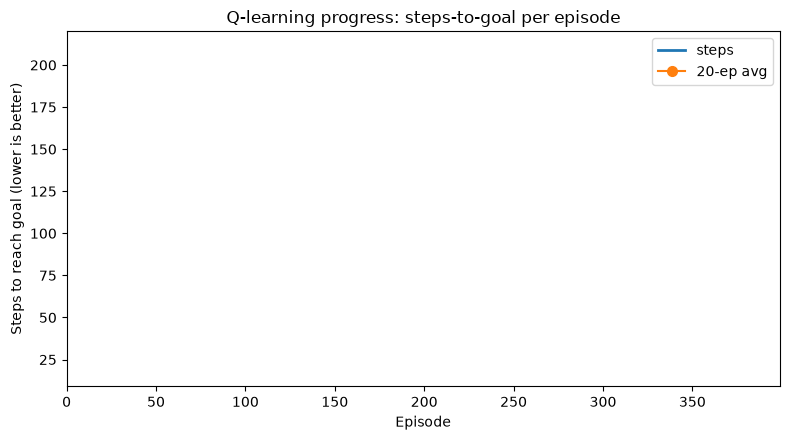

In [5]:
EPISODES = 400
_, steps = run_q_learning_with_stats(GRID, episodes=EPISODES)

# Prepare animated plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_title("Q-learning progress: steps-to-goal per episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps to reach goal (lower is better)")
ax.set_xlim(0, EPISODES - 1)

# Pad y-limits a bit for nicer visuals
y_min = max(1, int(steps.min() * 0.9))
y_max = int(steps.max() * 1.1)
ax.set_ylim(y_min, y_max)

(line,) = ax.plot([], [], lw=2)
(dot,) = ax.plot([], [], marker="o", markersize=7)

# Optional: show a running average too (smoothed)
window = 20
smoothed = np.convolve(steps, np.ones(window) / window, mode="same")
(smooth_line,) = ax.plot([], [], lw=2)
ax.legend(["steps", f"{window}-ep avg"], loc="upper right")

xs = np.arange(EPISODES)

def init():
    line.set_data([], [])
    dot.set_data([], [])
    smooth_line.set_data([], [])
    return line, dot, smooth_line

def update(i):
    # draw up to episode i
    line.set_data(xs[: i + 1], steps[: i + 1])
    smooth_line.set_data(xs[: i + 1], smoothed[: i + 1])

    # moving dot at current episode
    dot.set_data([xs[i]], [steps[i]])

    ax.set_title(f"Q-learning progress (episode {i+1}/{EPISODES})")
    return line, dot, smooth_line

animation.FuncAnimation(
    fig,
    update,
    frames=EPISODES,
    init_func=init,
    interval=FRAME_MS,  # <-- speed control here
    blit=True,
    repeat=False,
)

plt.tight_layout()
plt.show()